In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
results = pd.read_csv(
    '../data/raw/results.csv'
)

elo = pd.read_csv(
    '../data/raw/elo_ratings.csv'
)

In [37]:
results['date'] = pd.to_datetime(
    results['date']
)

elo['snapshot_date'] = pd.to_datetime(
    elo['snapshot_date']
)

In [38]:
recent_matches = results[
    results['date'] >= '2018-01-01'
].copy()


In [39]:
latest_elo = (

    elo.sort_values('snapshot_date')

       .groupby('country')

       .tail(1)
)


In [40]:
elo_dict = dict(

    zip(

        latest_elo['country'],
        latest_elo['rating']
    )
)


In [41]:
elite_teams = [

    'Argentina',
    'France',
    'Brazil',
    'Germany',
    'Spain',
    'England',
    'Portugal',
    'Netherlands',
    'Croatia',
    'Belgium',
    'Italy'
]



In [42]:
def calculate_team_stats(team):

    # --------------------------------------------------------
    # HOME + AWAY MATCHES
    # --------------------------------------------------------

    home_matches = recent_matches[
        recent_matches['home_team'] == team
    ]

    away_matches = recent_matches[
        recent_matches['away_team'] == team
    ]


    # --------------------------------------------------------
    # MATCH COUNTS
    # --------------------------------------------------------

    matches_played = (

        len(home_matches)

        +

        len(away_matches)
    )


    # Avoid division issues
    if matches_played < 5:

        return None


    # --------------------------------------------------------
    # GOALS
    # --------------------------------------------------------

    goals_scored = (

        home_matches['home_score'].sum()

        +

        away_matches['away_score'].sum()
    )



    goals_conceded = (

        home_matches['away_score'].sum()

        +

        away_matches['home_score'].sum()
    )



    # --------------------------------------------------------
    # WINS / DRAWS / LOSSES
    # --------------------------------------------------------

    home_wins = (

        home_matches['home_score']

        >

        home_matches['away_score']
    ).sum()



    away_wins = (

        away_matches['away_score']

        >

        away_matches['home_score']
    ).sum()



    wins = home_wins + away_wins



    home_draws = (

        home_matches['home_score']

        ==

        home_matches['away_score']
    ).sum()



    away_draws = (

        away_matches['away_score']

        ==

        away_matches['home_score']
    ).sum()



    draws = home_draws + away_draws

    losses = matches_played - wins - draws



    # --------------------------------------------------------
    # BASIC METRICS
    # --------------------------------------------------------

    win_pct = wins / matches_played

    avg_goals_scored = (

        goals_scored / matches_played
    )

    avg_goals_conceded = (

        goals_conceded / matches_played
    )



    # ========================================================
    # OPPONENT STRENGTH ANALYSIS
    # ========================================================

    opponent_elos = []

    elite_wins = 0

    world_cup_upsets = 0

    big_match_points = 0



    # --------------------------------------------------------
    # HOME MATCH ANALYSIS
    # --------------------------------------------------------

    for _, row in home_matches.iterrows():

        opponent = row['away_team']

        opponent_elo = elo_dict.get(
            opponent,
            1500
        )

        opponent_elos.append(opponent_elo)



        # ----------------------------------------------------
        # ELITE TEAM WIN
        # ----------------------------------------------------

        if opponent in elite_teams:

            if row['home_score'] > row['away_score']:

                elite_wins += 1

                big_match_points += 5



                # WC upset bonus
                if row['tournament'] == 'FIFA World Cup':

                    world_cup_upsets += 1

                    big_match_points += 10



        # ----------------------------------------------------
        # TOP ELO TEAM BONUS
        # ----------------------------------------------------

        if opponent_elo >= 1900:

            if row['home_score'] > row['away_score']:

                big_match_points += 7



    # --------------------------------------------------------
    # AWAY MATCH ANALYSIS
    # --------------------------------------------------------

    for _, row in away_matches.iterrows():

        opponent = row['home_team']

        opponent_elo = elo_dict.get(
            opponent,
            1500
        )

        opponent_elos.append(opponent_elo)



        # ----------------------------------------------------
        # ELITE TEAM WIN
        # ----------------------------------------------------

        if opponent in elite_teams:

            if row['away_score'] > row['home_score']:

                elite_wins += 1

                big_match_points += 5



                # WC upset bonus
                if row['tournament'] == 'FIFA World Cup':

                    world_cup_upsets += 1

                    big_match_points += 10



        # ----------------------------------------------------
        # TOP ELO TEAM BONUS
        # ----------------------------------------------------

        if opponent_elo >= 1900:

            if row['away_score'] > row['home_score']:

                big_match_points += 7



    # ========================================================
    # OPPONENT QUALITY
    # ========================================================

    avg_opponent_elo = np.mean(
        opponent_elos
    )



    # ========================================================
    # SAMPLE SIZE STABILITY
    # ========================================================

    sample_weight = np.log1p(
        matches_played
    )



    # ========================================================
    # ADJUSTED STRENGTH SCORE
    # ========================================================

    adjusted_strength = (

        (
            win_pct * 0.35
        )

        +

        (
            avg_goals_scored * 0.20
        )

        -

        (
            avg_goals_conceded * 0.15
        )

        +

        (
            avg_opponent_elo / 2500 * 0.20
        )

        +

        (
            big_match_points / 100 * 0.10
        )

    ) * sample_weight * 100



    # ========================================================
    # RETURN PROFILE
    # ========================================================

    return {

        'team': team,

        'matches_played': matches_played,

        'wins': wins,

        'draws': draws,

        'losses': losses,

        'win_pct': win_pct,

        'avg_goals_scored':
            avg_goals_scored,

        'avg_goals_conceded':
            avg_goals_conceded,

        'avg_opponent_elo':
            avg_opponent_elo,

        'elite_wins':
            elite_wins,

        'world_cup_upsets':
            world_cup_upsets,

        'big_match_points':
            big_match_points,

        'adjusted_strength':
            adjusted_strength
    }

In [43]:
all_teams = pd.unique(

    recent_matches[
        ['home_team', 'away_team']
    ].values.ravel()
)


In [44]:
team_profiles = []

for team in all_teams:

    stats = calculate_team_stats(team)

    if stats is not None:

        team_profiles.append(stats)

In [45]:
team_profiles_df = pd.DataFrame(
    team_profiles
)


In [47]:
team_profiles_df = team_profiles_df[

    team_profiles_df['matches_played'] >= 20
]


In [48]:
top_teams = (

    team_profiles_df

    .sort_values(
        by='adjusted_strength',
        ascending=False
    )
)


In [49]:
top_teams.head(20)

,team,matches_played,wins,draws,losses,win_pct,avg_goals_scored,avg_goals_conceded,avg_opponent_elo,elite_wins,world_cup_upsets,big_match_points,adjusted_strength
77,France,111,71,22,18,0.639640,2.081081,0.855856,1711.279279,22,4,262,429.673139
82,Spain,107,65,30,12,0.607477,2.317757,0.785047,1716.383178,14,0,175,407.683405
150,Belgium,105,66,19,20,0.628571,2.323810,0.819048,1655.895238,8,3,133,385.841936
90,Argentina,106,72,19,15,0.679245,1.990566,0.603774,1712.584906,7,1,129,379.101842
91,Japan,112,71,16,25,0.633929,2.276786,0.767857,1647.937500,5,2,94,372.465484
94,England,110,69,20,21,0.627273,2.145455,0.645455,1648.300000,9,0,87,362.955101
104,Brazil,104,64,22,18,0.615385,1.942308,0.644231,1741.038462,6,0,114,353.931179
101,Portugal,105,63,23,19,0.600000,2.219048,0.800000,1682.866667,6,0,79,348.563559
93,Netherlands,100,56,24,20,0.560000,2.200000,0.940000,1702.250000,7,0,98,336.525358
110,Morocco,119,78,26,15,0.655462,1.815126,0.512605,1597.378151,3,2,49,331.455514


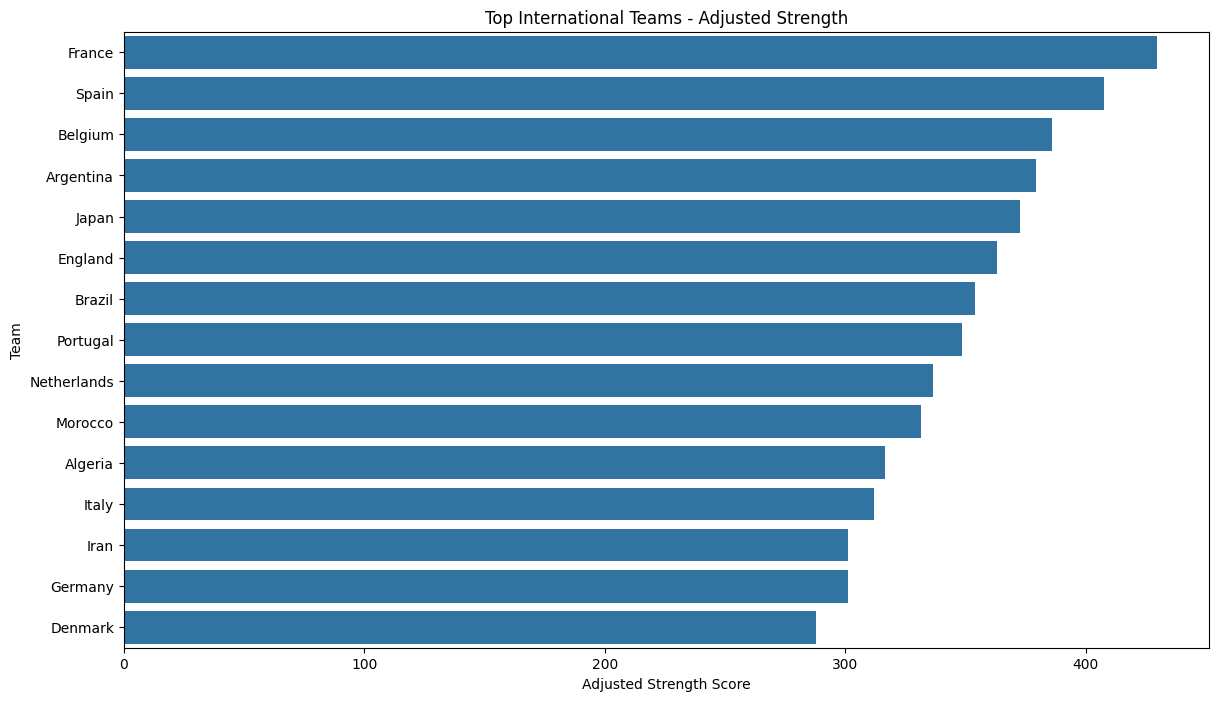

In [50]:
plt.figure(figsize=(14,8))

sns.barplot(

    data=top_teams.head(15),

    x='adjusted_strength',

    y='team'
)

plt.title(
    'Top International Teams - Adjusted Strength'
)

plt.xlabel('Adjusted Strength Score')

plt.ylabel('Team')

plt.show()

In [51]:
team_stats_dict = (

    team_profiles_df

    .set_index('team')

    .to_dict(orient='index')
)

In [52]:
team_stats_dict['France']

{'matches_played': 111,
 'wins': 71,
 'draws': 22,
 'losses': 18,
 'win_pct': 0.6396396396396397,
 'avg_goals_scored': 2.081081081081081,
 'avg_goals_conceded': 0.8558558558558559,
 'avg_opponent_elo': 1711.2792792792793,
 'elite_wins': 22,
 'world_cup_upsets': 4,
 'big_match_points': 262,
 'adjusted_strength': 429.67313862395036}

In [53]:
team_profiles_df.to_csv(

    '../data/cleaned/team_strength_profiles.csv',

    index=False
)

